# Data understanding and preprocessing

Initial inspection of one bumpy accelerometer recording, following the data inspection methods in `course_files/practical/preprocessing/instruction_3.ipynb` and the sampling concepts from the September 4 lecture.

## 1. Setup

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Data understanding

### Load and describe the recording

Inspect the first rows, column types, and descriptive statistics to understand the measurements before preprocessing.

In [11]:
df = pd.read_csv(
    "data/recordings/raw/bumpy/lars/cb_2_bumpy_lars/Accelerometer.csv"
)

display(df.head())
df.info()
display(df.describe())

,time,seconds_elapsed,z,y,x
0,1788862107461369600,0.045370,-0.713455,-0.347207,-0.227989
1,1788862107471376400,0.055376,-0.676802,-0.322843,-0.221322
2,1788862107481384400,0.065385,-0.487768,-0.293544,0.057028
3,1788862107491391500,0.075392,-0.417952,-0.196537,0.635013
4,1788862107501398500,0.085398,-0.421297,-0.185778,0.567141


<class 'pandas.DataFrame'>
RangeIndex: 4170 entries, 0 to 4169
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             4170 non-null   int64  
 1   seconds_elapsed  4170 non-null   float64
 2   z                4170 non-null   float64
 3   y                4170 non-null   float64
 4   x                4170 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 163.0 KB


,time,seconds_elapsed,z,y,x
count,4.170000e+03,4170.000000,4170.000000,4170.000000,4170.000000
mean,1.788862e+18,20.904847,0.266718,-0.441304,0.030345
std,1.204749e+10,12.047494,2.375639,2.328544,1.796351
min,1.788862e+18,0.045370,-22.102477,-19.197088,-11.743799
25%,1.788862e+18,10.475228,-1.032784,-1.609083,-1.012685
50%,1.788862e+18,20.904914,0.216784,-0.178798,0.008569
75%,1.788862e+18,31.334369,1.704822,0.964918,1.014154
max,1.788862e+18,41.765532,15.543861,13.260875,13.117124


Each row represents one sensor measurement. The columns capture timing via `time` (Unix epoch in nanoseconds) and `seconds_elapsed`, alongside tri-axial acceleration values `x`, `y`, and `z` in m/s². This recording contains 4,170 measurements spanning approximately 41.7 seconds.

Mean acceleration values lie near zero, while individual axis values range from approximately −22.1 to +15.5 m/s². These extremes require further inspection to distinguish road vibration from phone handling or other movements.

### Check data quality

Check missing values, duplicate rows, and duplicate timestamps. Then inspect the spacing between measurements: missing timestamps can leave gaps without producing missing cells.

In [12]:
display(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate timestamps:", df["time"].duplicated().sum())

time               0
seconds_elapsed    0
z                  0
y                  0
x                  0
dtype: int64

Duplicate rows: 0
Duplicate timestamps: 0


In [13]:
dt = df["seconds_elapsed"].diff().dropna()

display(dt.describe())
print("Non-positive intervals:", (dt <= 0).sum())
print("Estimated sampling rate (Hz):", 1 / dt.median())

count    4169.000000
mean        0.010007
std         0.000029
min         0.010005
25%         0.010007
50%         0.010007
75%         0.010007
max         0.011883
Name: seconds_elapsed, dtype: float64

Non-positive intervals: 0
Estimated sampling rate (Hz): 99.93168732308945


No missing values, duplicate rows, or duplicate timestamps were detected. No imputation or duplicate removal is needed for this recording.

Sampling intervals are approximately 0.010 seconds, corresponding to 99.93 Hz. All timestamps increase, and the largest interval is 0.0119 seconds. Sampling is approximately regular, with no substantial gaps detected.

These checks support continuing to raw-signal visualization; they do not yet establish whether unusual acceleration values need cleaning.

### Visualize the raw acceleration

Plot each acceleration axis against elapsed time to inspect fluctuations and isolated peaks before choosing any filtering or outlier treatment. The panels share the same scale so their amplitudes can be compared. This follows the raw-signal visualization approach in `instruction_3.ipynb`.

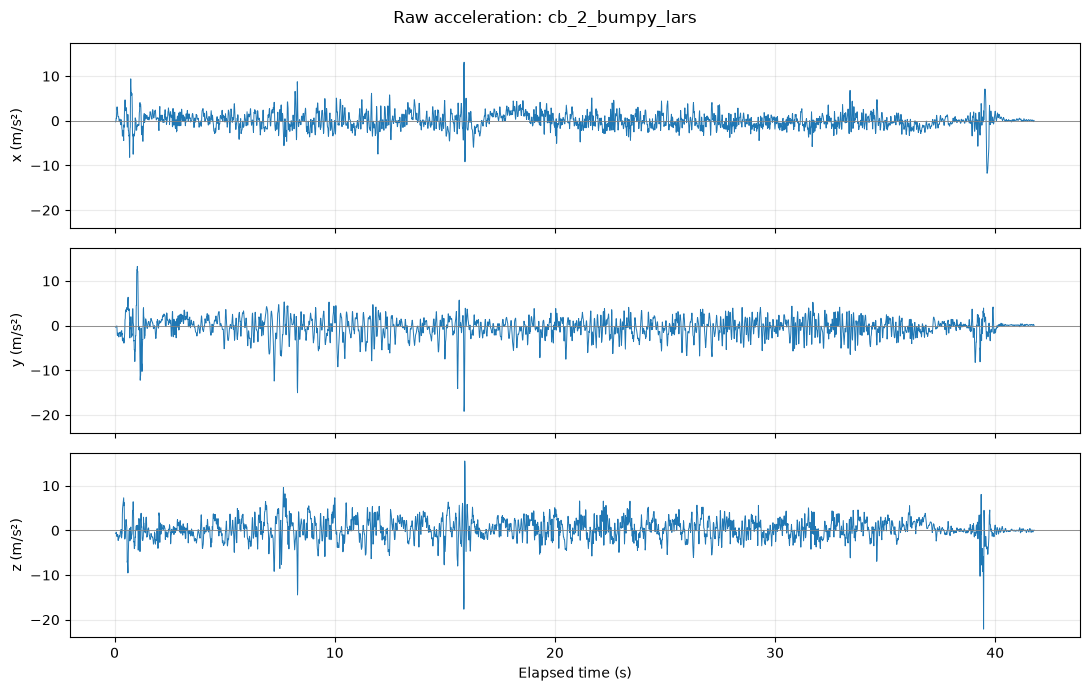

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True, sharey=True)

for ax, component in zip(axes, ["x", "y", "z"]):
    ax.plot(df["seconds_elapsed"], df[component], linewidth=0.7)
    ax.axhline(0, color="grey", linewidth=0.6)
    ax.set_ylabel(f"{component} (m/s²)")
    ax.grid(alpha=0.25)

axes[-1].set_xlabel("Elapsed time (s)")
fig.suptitle("Raw acceleration: cb_2_bumpy_lars")
fig.tight_layout()
plt.show()

The acceleration fluctuates around zero throughout most of the recording, with larger variations visible in the y and z axes. Several pronounced peaks occur, including around 16 and 39 seconds, followed by a relatively quiet period after approximately 40 seconds.

The plot alone cannot determine whether these peaks represent road impacts, phone handling, or other movements. No filtering or peak removal is applied at this stage.